# V3: Evaluating V2 vs V3 on Validation Only
## 2.1 Loading the Best Model

- Random seed: 42
- Batch size: 32
- Embedding dimension: 128
- Optimizer: Adam
- Learning rate: 0.001
- Epochs: 15
- Checkpoint criterion: Lowest validation loss
- Number of Heads = 4
- Number of Layers = 2
- Feed Forward Dimension = 256
- Dropout = 0.1

In [1]:
from src.v3.model import TransformerBugFixClassifier
from torch.utils.data import DataLoader
from src.v2.data import BugFixDataset, collate_batch
import torch
import pandas as pd
import torch.nn as nn
import json

with open('data/processed/token_to_id.json', 'r') as f:
    token_to_id = json.load(f)

with open('data/processed/label_to_id.json', 'r') as f:
    label_to_id = json.load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerBugFixClassifier(vocab_size=len(token_to_id), embedding_dim=128, num_heads=4, num_layers=2, feedforward_dim=256, num_classes=len(label_to_id), max_length=1024, padding_index=0,dropout=.1).to(device)
criterion = nn.CrossEntropyLoss()

checkpoint = torch.load('models/v3_best_model.pt', weights_only=True)
model.load_state_dict(checkpoint['model_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['validation_loss']

best_epoch = checkpoint['epoch']
best_validation_loss = checkpoint['validation_loss']

print(f'Best Epoch: {best_epoch}')
print(f'Best Validation Loss: {best_validation_loss}')

validation_dataset = BugFixDataset(pd.read_parquet('data/processed/validation_v2_label_id.parquet'))
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False, collate_fn=collate_batch)

Best Epoch: 10
Best Validation Loss: 0.314357266020779


## 5.2 Evaluating V3 Model

In [2]:
from src.v2.evaluate import evaluate_model
from sklearn.metrics import classification_report
import json

v3_accuracy, average_loss, all_predictions, all_labels = evaluate_model(model, criterion, validation_loader)

assert len(all_predictions) == len(validation_dataset)
assert len(all_labels) == len(validation_dataset)

with open('data/processed/id_to_label.json', 'r') as file:
    id_to_label = json.load(file)

print(id_to_label)
print()

class_names = [id_to_label[str(i)] for i in range(len(id_to_label))]
print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4))

c:\Program Files\Python312\Lib\site-packages\torch\nn\modules\transformer.py:529: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:181.)
  output = torch._nested_tensor_from_mask(


{'0': 'assignment', '1': 'call', '2': 'control_flow', '3': 'expression', '4': 'identifier'}

              precision    recall  f1-score   support

  assignment     0.7982    0.8460    0.8214       734
        call     0.8963    0.9385    0.9169      2746
control_flow     0.9202    0.9618    0.9405       863
  expression     0.8517    0.7304    0.7864      1187
  identifier     0.8308    0.6243    0.7129       173

    accuracy                         0.8773      5703
   macro avg     0.8594    0.8202    0.8356      5703
weighted avg     0.8760    0.8773    0.8748      5703



## 5.3 Confusion Matrix Heatmap

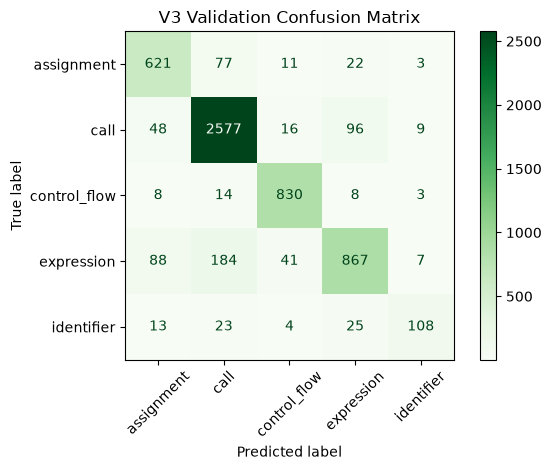

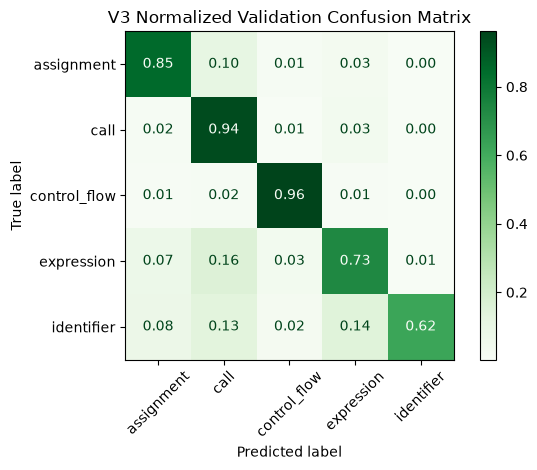

In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

confusion = confusion_matrix(all_labels, all_predictions, labels=range(len(class_names)))
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names)

cm_display.plot(cmap='Greens', values_format='d')
plt.xticks(rotation=45)
plt.title('V3 Validation Confusion Matrix')
plt.tight_layout()
plt.show()

normalized_confusion = confusion_matrix(all_labels, all_predictions, labels=range(len(class_names)), normalize='true')

cm_display = ConfusionMatrixDisplay(confusion_matrix=normalized_confusion, display_labels=class_names)

cm_display.plot(cmap='Greens', values_format='.2f')
plt.xticks(rotation=45)
plt.title('V3 Normalized Validation Confusion Matrix')
plt.tight_layout()
plt.show()

## 5.4 V2 Evaluation on Validation

{'0': 'assignment', '1': 'call', '2': 'control_flow', '3': 'expression', '4': 'identifier'}

              precision    recall  f1-score   support

  assignment     0.7982    0.8460    0.8214       734
        call     0.8963    0.9385    0.9169      2746
control_flow     0.9202    0.9618    0.9405       863
  expression     0.8517    0.7304    0.7864      1187
  identifier     0.8308    0.6243    0.7129       173

    accuracy                         0.8773      5703
   macro avg     0.8594    0.8202    0.8356      5703
weighted avg     0.8760    0.8773    0.8748      5703



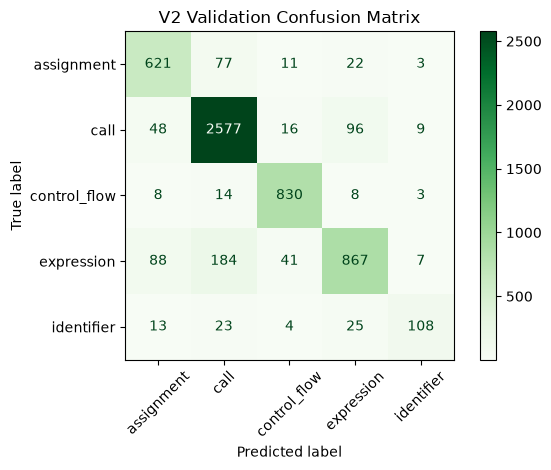

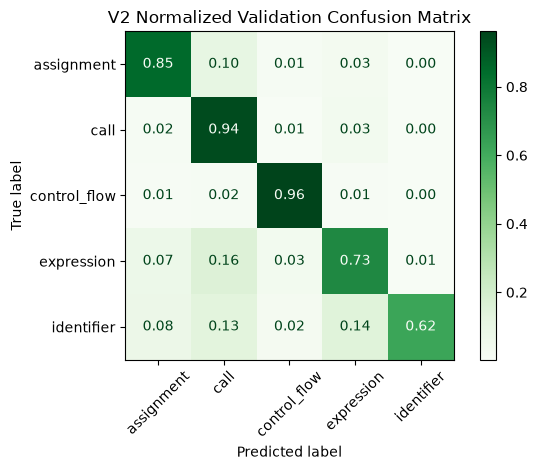

In [4]:
from src.v2.evaluate import evaluate_model
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import json

v2_accuracy, average_loss, all_predictions, all_labels = evaluate_model(model, criterion, validation_loader)

assert len(all_predictions) == len(validation_dataset)
assert len(all_labels) == len(validation_dataset)

with open('data/processed/id_to_label.json', 'r') as file:
    id_to_label = json.load(file)

print(id_to_label)
print()

class_names = [id_to_label[str(i)] for i in range(len(id_to_label))]
print(classification_report(all_labels, all_predictions, target_names=class_names, digits=4))


confusion = confusion_matrix(all_labels, all_predictions, labels=range(len(class_names)))
cm_display = ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names)

cm_display.plot(cmap='Greens', values_format='d')
plt.xticks(rotation=45)
plt.title('V2 Validation Confusion Matrix')
plt.tight_layout()
plt.show()

normalized_confusion = confusion_matrix(all_labels, all_predictions, labels=range(len(class_names)), normalize='true')

cm_display = ConfusionMatrixDisplay(confusion_matrix=normalized_confusion, display_labels=class_names)

cm_display.plot(cmap='Greens', values_format='.2f')
plt.xticks(rotation=45)
plt.title('V2 Normalized Validation Confusion Matrix')
plt.tight_layout()
plt.show()

## 5.5 V3 Validation Error Analysis
V3 was able to outperform V2 across all five classes. Validation accuracy increased from `.7780` to `.8773`, while the macro F1 increased from `0.7249` to `0.8356`. The already strong `assignment`, `call`, and `control_flow` classes continued to improve. More importantly, the `expression` F1 increased from `0.5786` to `.7864` and `identifier` F1 increased from `0.5941` to `0.7129`.

Some confusion remain within the two target classes. The model predicted `expression` changes as call in approximately `15.5%` of expression examples. It predicted identifier changes as expression in approximately `14.5%` of identifier examples and as `call` in approximately `13.3%` These results strongly support the hypothesis that sequence-aware contextualization benefits the weaker classes, but they do not prove that contextual information alone caused the imrpovement beacause V3 also introduced additional model capacity. `Identifier` results should be interpreted cautiously because the class only contained only `173` validation examples. 